# 05 — Segmentación: PCA + KMeans

Construye un panel de features por cliente, aplica PCA(2) y KMeans para encontrar segmentos.

## 0. Setup

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.analytics.clustering import run_pca_kmeans, save_artifacts

In [2]:
ROOT = Path('..')

cltv_path    = ROOT / 'data' / 'processed' / 'cltv.parquet'
metrics_path = ROOT / 'data' / 'processed' / 'customer_metrics.parquet'

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
PALETTE = sns.color_palette('crest', as_cmap=False)

## 1. Construcción del panel de features

Combina CLTV + métricas adicionales por `customer_sk`.

In [3]:
cltv    = pd.read_parquet(cltv_path)
metrics = pd.read_parquet(metrics_path)
panel = cltv.merge(metrics[['customer_sk','aov','recency_days','return_rate']],
                   on='customer_sk')
print('clientes en panel:', len(panel))
panel.head()

clientes en panel: 5750


,customer_sk,customer_id,full_name,gross_revenue,net_revenue,total_cost,margin_rate,frequency,first_purchase,last_purchase,active_months,window_months,retention_rate,cltv,aov,recency_days,return_rate
0,213,212,Sergio Álvarez Martínez,21281.51,20781.53,12768.43,0.385588,34,2020-01-20,2025-08-05,29,72,0.402778,109734.952778,611.221471,147,0.023494
1,184,183,Alejandro Pérez Pérez,24922.00,23932.15,14916.63,0.376712,33,2020-01-05,2025-10-18,26,72,0.361111,107434.946667,725.216667,73,0.039718
2,229,228,Carlos García López,22268.34,22148.45,13360.50,0.396775,30,2020-01-12,2025-12-22,27,72,0.375000,98864.437500,738.281667,8,0.005384
3,344,343,Alejandro Fernández Pérez,21167.80,20682.93,12676.26,0.387115,30,2020-07-18,2025-11-14,27,72,0.375000,90075.037500,689.431000,46,0.022906
4,503,500,Sergio Martínez Gómez,19215.39,19035.50,11516.76,0.394985,32,2020-03-30,2025-10-19,26,72,0.361111,86883.217778,594.859375,72,0.009362


## 2. Inspección de las features

### 2.1. Distribuciones

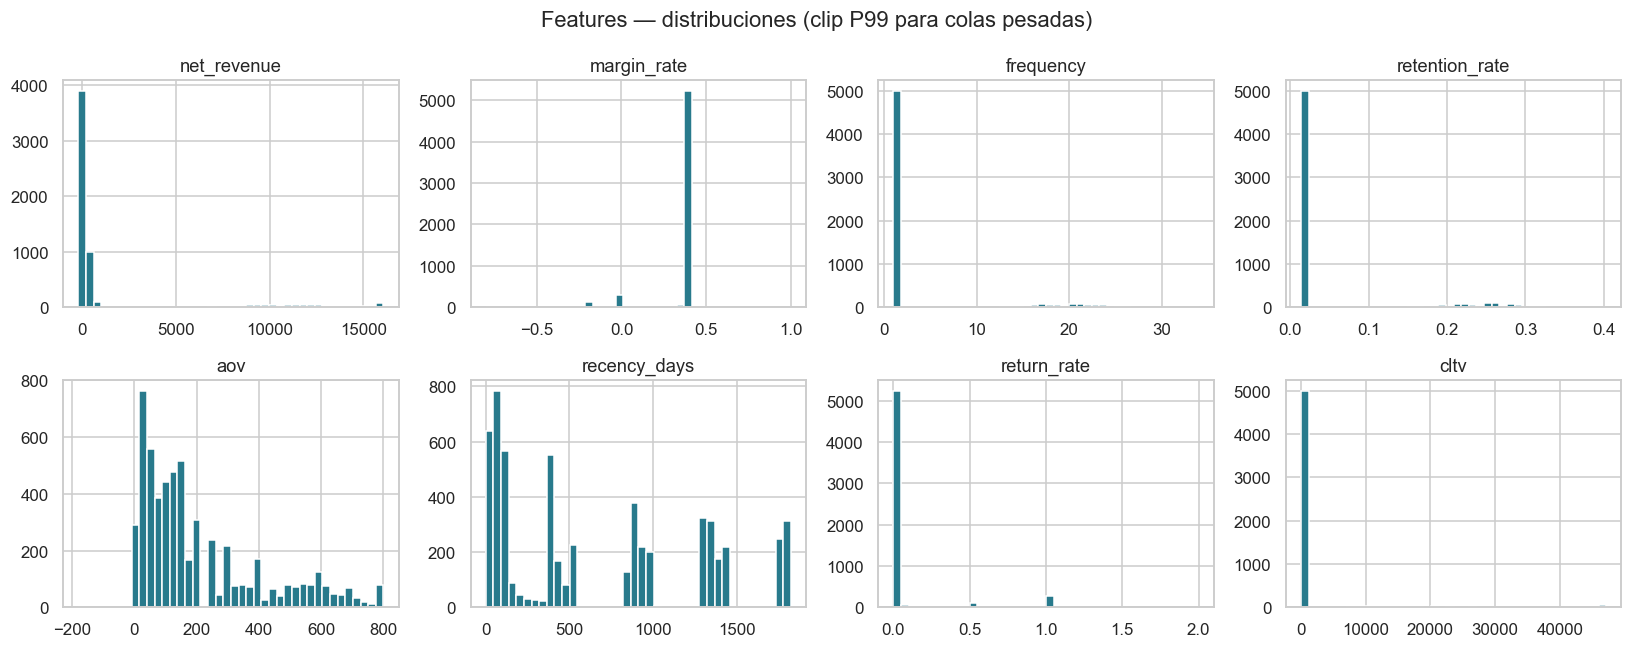

In [4]:
features = ['net_revenue','margin_rate','frequency','retention_rate',
            'aov','recency_days','return_rate','cltv']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.flatten(), features):
    s = panel[c].astype(float).dropna()
    if c in ('net_revenue','aov','cltv'):
        s = s.clip(upper=s.quantile(0.99))
    ax.hist(s, bins=40, color=PALETTE[3], edgecolor='white')
    ax.set_title(c)
plt.suptitle('Features — distribuciones (clip P99 para colas pesadas)')
plt.tight_layout()
plt.show()

### 2.2. Correlaciones — confirma si hay redundancia (justifica PCA)

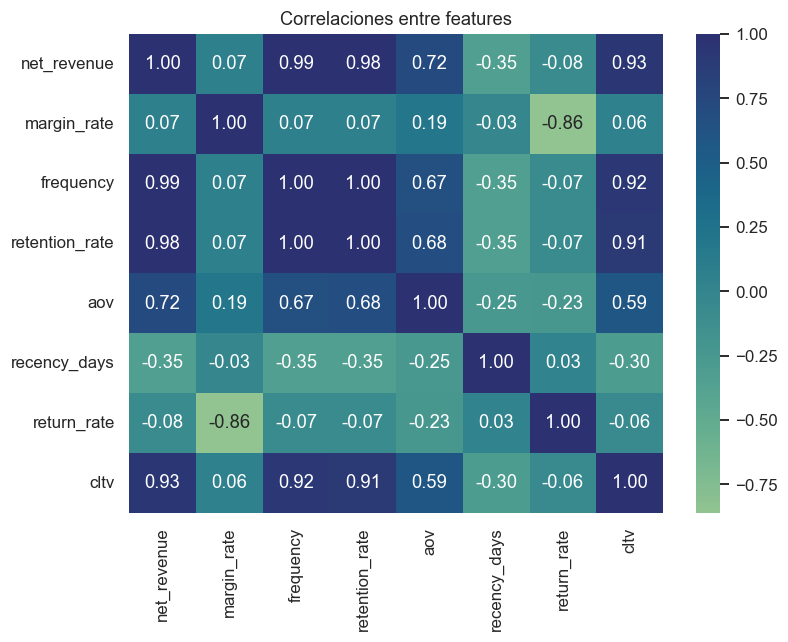

In [5]:
corr = panel[features].corr().round(2)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='crest', center=0, ax=ax)
ax.set_title('Correlaciones entre features')
plt.tight_layout()
plt.show()

## 3. PCA + KMeans

Ejecuta el pipeline (estandarización → PCA(2) → elbow → KMeans).

In [6]:
res = run_pca_kmeans(panel, features)
print('Varianza explicada PCA:', res.explained_variance.round(3))
print('Total acumulado:', res.explained_variance.sum().round(3))

Varianza explicada PCA: [0.571 0.232]
Total acumulado: 0.803


### 3.1. Curva del codo

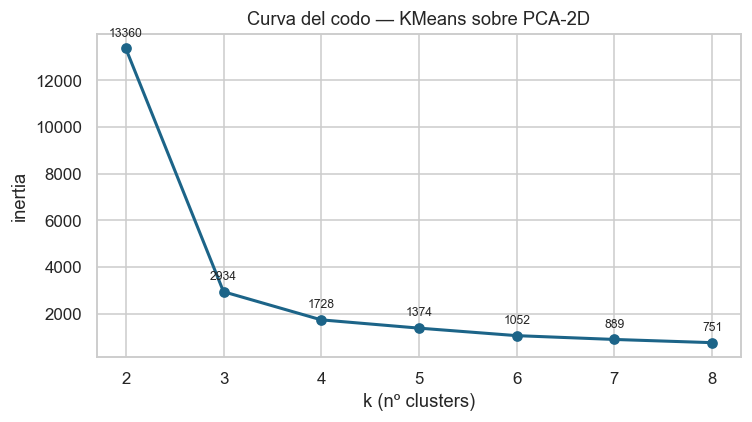

In [7]:
ks = list(res.inertia_curve.keys())
ins = list(res.inertia_curve.values())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, ins, marker='o', color=PALETTE[4], lw=2)
ax.set_xlabel('k (nº clusters)')
ax.set_ylabel('inertia')
ax.set_title('Curva del codo — KMeans sobre PCA-2D')
ax.set_xticks(ks)
for k, v in zip(ks, ins):
    ax.annotate(f'{v:.0f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 3.2. Varianza explicada por componente

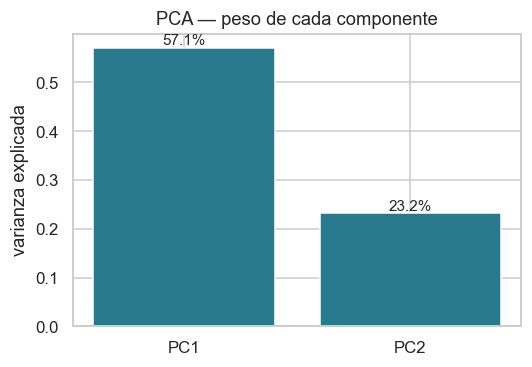

In [8]:
var = res.explained_variance
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar([f'PC{i+1}' for i in range(len(var))], var, color=PALETTE[3])
for i, v in enumerate(var):
    ax.text(i, v, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('varianza explicada')
ax.set_title('PCA — peso de cada componente')
plt.tight_layout()
plt.show()

## 4. Visualización 2D de los clusters

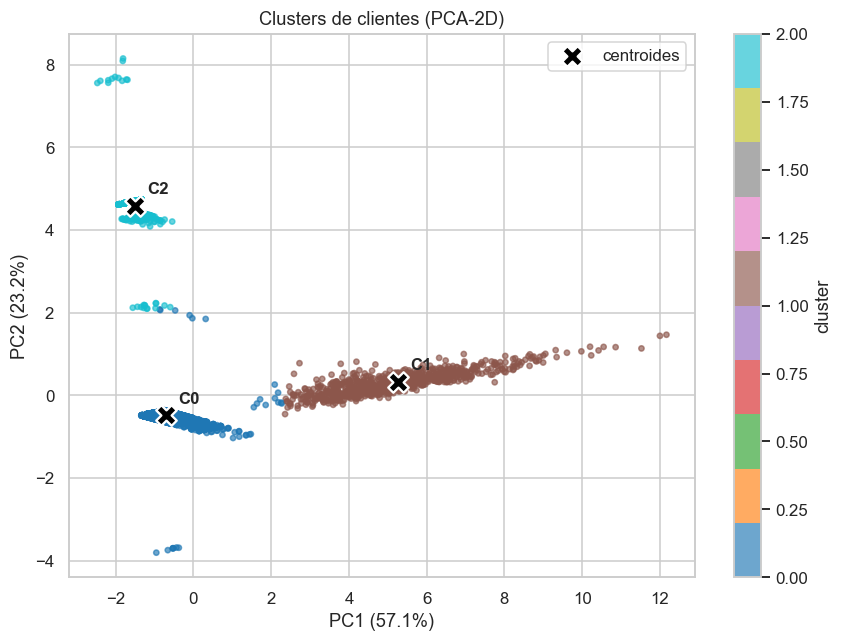

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
centers = res.kmeans.cluster_centers_
sc = ax.scatter(res.df['pc1'], res.df['pc2'], c=res.df['cluster'],
                cmap='tab10', s=12, alpha=0.65)
ax.scatter(centers[:, 0], centers[:, 1], marker='X', c='black', s=180,
           edgecolor='white', linewidth=1.5, label='centroides')
for i, (x, y) in enumerate(centers):
    ax.annotate(f'C{i}', (x, y), fontsize=11, fontweight='bold',
                xytext=(8, 8), textcoords='offset points')
ax.set_xlabel(f'PC1 ({res.explained_variance[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({res.explained_variance[1]*100:.1f}%)')
ax.set_title('Clusters de clientes (PCA-2D)')
ax.legend(loc='upper right')
plt.colorbar(sc, label='cluster')
plt.tight_layout()
plt.show()

## 5. Caracterización de clusters

### 5.1. Tamaño de cada cluster

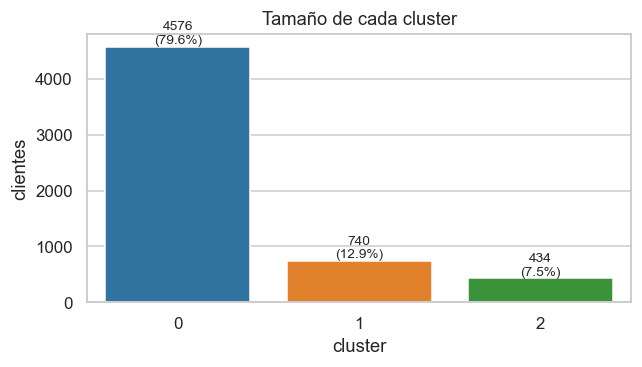

,cluster,n,pct
0,0,4576,79.6
1,1,740,12.9
2,2,434,7.5


In [10]:
sizes = res.df.groupby('cluster').size().rename('n').reset_index()
sizes['pct'] = (sizes['n'] / sizes['n'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=sizes, x='cluster', y='n', hue='cluster',
            palette='tab10', ax=ax, legend=False)
for i, (n, p) in enumerate(zip(sizes['n'], sizes['pct'])):
    ax.text(i, n, f'{n}\n({p}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Tamaño de cada cluster')
ax.set_ylabel('clientes')
plt.tight_layout()
plt.show()

sizes

### 5.2. Perfil — z-score de cada feature por cluster

Un valor positivo indica que el cluster está por encima de la media en esa feature.

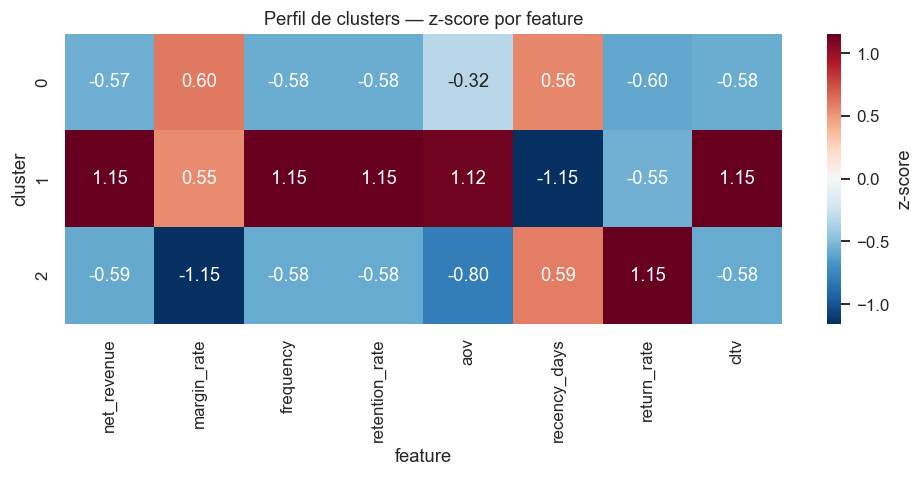

,net_revenue,margin_rate,frequency,retention_rate,aov,recency_days,return_rate,cltv
cluster,,,,,,,,
0,176.82,0.40,1.02,0.01,167.54,754.67,0.00,7.43
1,11592.77,0.39,20.12,0.24,576.28,117.24,0.03,24550.72
2,33.74,-0.06,1.00,0.01,33.74,765.58,0.86,-0.09


In [11]:
profile = res.df.groupby('cluster')[features].mean()
z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label':'z-score'})
ax.set_title('Perfil de clusters — z-score por feature')
ax.set_xlabel('feature')
ax.set_ylabel('cluster')
plt.tight_layout()
plt.show()

profile.round(2)

## 6. Persistencia de los artefactos

In [12]:
save_artifacts(res, ROOT / 'models')
print('artefactos guardados en:', ROOT / 'models')

artefactos guardados en: ../models
